---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.12 (Polynomial Regression and Bias-Variance Tradeoff)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

- Recap (Linear Regression using Scikit-Learn on Advertising dataset)
- Overview of Polynomial Regression
- Simple Linear Regression
- Simple Polynomial Linear Regression
- Bias-Variance Tradeoff (Underfitting vs Overfitting)
- Techniques to prevent Overfitting
- Polynomial Linear Regression on Advertising dataset

# 1. A Recap of Linear Regression using Scikit-Learn

## a. Load and Analyze Features of your Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("datasets/advertising4D.csv")
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


<font face = "Garamond" color=green size=4>**Assumptions for Linear Regression:**
1. <font face = "Garamond" color=green size=3>**Linear relationship:** All the feature variables should be somehow correlated with the output variable.</font>

2. <font face = "Garamond" color=green size=3>**Independence:** The feature variables should NOT have any correlation with eachother.</font>

3. <font face = "Garamond" color=green size=3>**Homoscedasticity:** The variance of residuals (errors) of the regression line is the same for any value of X.</font>

4. <font face = "Garamond" color=green size=3>**Normality:** The residuals (errors) of the regression line are approximately normally distributed.</font>

## b. Train Test Split

In [3]:
X = df.drop('sales', axis=1)
y = df['sales']

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
len(X_train), len(X_test), len(y_train), len(y_test)

(160, 40, 160, 40)

## c. Train Model on Training Data Set

In [5]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)

LinearRegression()

In [6]:
print("lr_model.intercept_: ", lr_model.intercept_)
print("lr_model.coef_: ", lr_model.coef_)

lr_model.intercept_:  3.055121653762061
lr_model.coef_:  [ 0.04597903  0.18579595 -0.0030992 ]


## d. Evaluate using Test Data

In [7]:
y_predicted = lr_model.predict(X_test)
test_residuals = y_test - y_predicted
test_residuals

179    0.127337
166   -2.797131
187    0.182347
119   -0.250738
186    0.523071
134   -0.920164
142    0.855536
12    -1.266623
118    0.454900
178   -4.331399
138   -0.180801
43    -1.147050
194    0.766077
11     0.026475
44    -0.349956
101    0.685010
49     1.509119
4     -0.293733
149    0.259924
31     0.540625
188   -2.876221
116    0.167055
33    -1.582141
0      1.656481
181   -1.819920
161   -0.194229
2     -2.859220
183    2.154606
125    1.423384
81    -2.428296
176    0.175563
145    0.468901
124    0.321442
55     2.507281
153    0.809411
137   -0.024063
182    2.093866
156    0.001833
104    0.336298
106    1.043693
Name: sales, dtype: float64

#### (i) Mean Absolute Error:
- It is the average of the absolute differences between the predicted and actual values. Lower the value of MAE, better the model.
$$ \large MAE = \frac{1}{n}\sum_{i=1}^n|y_i - \hat{y}_i| \hspace{12cm}$$

#### (ii) Mean Squared Error:
- It is the average of the squared differences between the predicted and actual values. Lower the value of MSE, better the model.
$$\large MSE = \frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2\hspace{12.4cm}$$

#### (iii) Root Mean Squared Error:
- It is the square root of the mean squared error. Lower the value of RMSE, better the model.
$$ \large RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2}\hspace{11.5cm}$$


#### (iv)  R-squared Value:
- It is a statistical measure that represents the proportion of the variance for a dependent variable that's explained by an independent variable or variables. R-squared value ranges from 0 to 1, and the closer it is to 1, the better the model.
$$ \large R^2 =  1 - \frac{\sum_{i=1}^n(y_i - \hat{y}_i)^2}{\sum_{i=1}^n(y_i - \bar{y})^2}\hspace{14cm}$$



#### (v)  Adjusted R-squared Value:
- The limitation or R2 score is that, if you add more features to your model, the R2 score will either increase or stay the same, but will never decrease.
- Adjusted R2 score is a modified form of R2 score, whose value increases if new predictors tend to improve model's performance and decreases if new predictors do not improve performance as expected.

$$ \large R_a^2 =  1 - \large [\frac{(1-R^2)(n-1)}{n-m-1}]$$

>- where n is number of observations in sample and m is number of features/predictors/independent variables in model

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predicted)
n = len(X_test)
m = 3
r2_adj = 1 - ((1-r2)*(n-1)/(n-m-1))
print("MAE:", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2 Score: ", r2)
print("R2 Adjusted: ", r2_adj)
print("Mean of Sales Column: ", df['sales'].mean())

MAE: 1.0602981028984602
MSE:  2.1533134134530854
RMSE:  1.4674172594913437
R2 Score:  0.9175053931302267
R2 Adjusted:  0.9106308425577456
Mean of Sales Column:  14.0225


**Residual Plot:** is a plot of the residuals (predicted - actual) versus the predicted values. If the model is a good fit, the residuals should be randomly distributed around a horizontal line at zero.

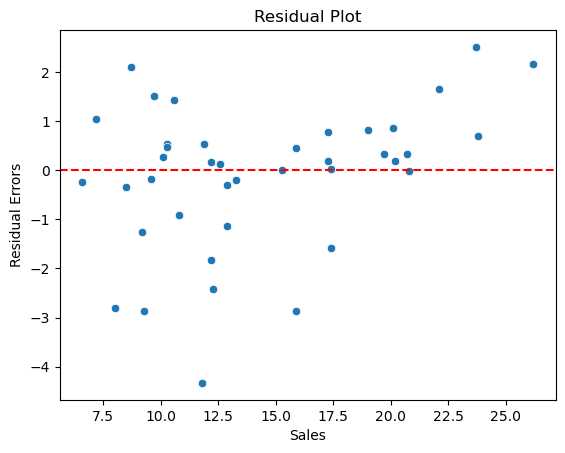

In [9]:
test_residuals = y_test - y_predicted
sns.scatterplot(x=y_test, y=test_residuals)
plt.title("Residual Plot")
plt.xlabel('Sales')
plt.ylabel("Residual Errors")
plt.axhline(y=0, color='r', ls='--')
plt.show()

# 2. Polynomial Regression

<h3 align="center"><div class="alert alert-success" color=magenta style="margin: 20px">It is a form of linear regression, which estimates the relationship between X and y as an $n^{th}$ degree polynomial in X.</h3>

## a. Intuition Behind Polynomial Regression
<img align="center" width="800"  src="images/poly11.png"  >

## b. Simple Linear Regression on Non-Linear Dataset

**Generate dataset:**

$\large y = 0.8x^2+0.9x+2$

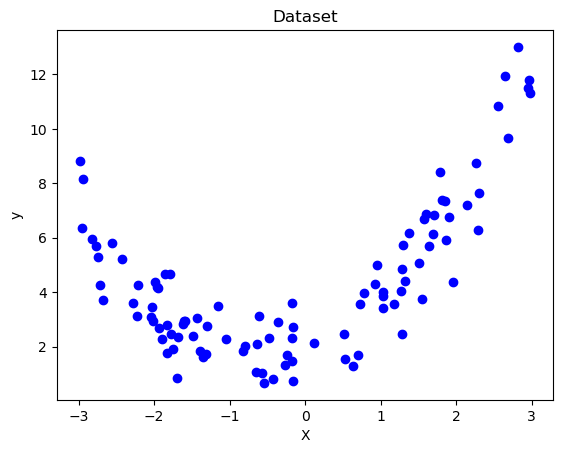

In [10]:
np.random.seed(54)
X = 6*np.random.rand(100, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(100, 1)

plt.scatter(X, y, color='blue')
plt.title('Dataset')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

**Splitting the dataset into the Training set and Test set**

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=54)

**Fitting Linear Regression to the dataset**

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [13]:
print("lr.coef_: ", lr.coef_)
print("lr.intercept_: ", lr.intercept_)

lr.coef_:  [[0.69255604]]
lr.intercept_:  [4.52291489]


**Evaluate the model**

In [14]:
y_predicted = lr.predict(X_test)
y_predicted.shape, y_test.shape

((20, 1), (20, 1))

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_predicted)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

RMSE:  2.3563137008458073
R2 Score:  0.41718575401462


**Visualizing the Linear Regression results**

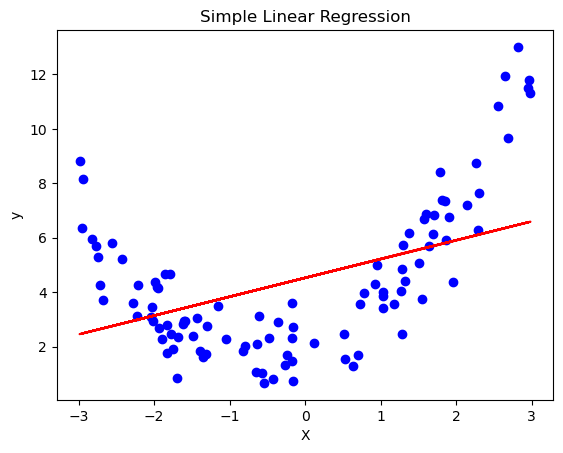

In [16]:
plt.scatter(X, y, color='blue')
plt.plot(X, lr.predict(X), color='red')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

<img align="right" width="400"  src="images/poly-intro.png"  >

## c. Simple Polynomial Linear Regression

- In order to improve on a LR model we consider higher order relationships on the features.
- There are two issues that polynomial regression is going to address for us:
    - `Higher order terms:` will identify the non-linear relationship among the input features and the output label.
    - `Interaction terms:` will identify if there is a SYNERGY between multiple input features.

<font face = "Courier New" color=green size=4>$\large \hspace{2 cm} \hat{y} \hspace{1 cm}=\hspace{1 cm} \beta_0 + \beta_1 x$</font><br>

<font face = "Courier New" color=green size=4>$\large \hspace{2 cm} \hat{y} \hspace{1 cm}=\hspace{1 cm} \beta_0 + \beta_1 x + \beta_2 x^2$</font><br>

<font face = "Courier New" color=green size=4>$\large \hspace{2 cm} \hat{y} \hspace{1 cm}=\hspace{1 cm} \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3$</font><br>

<font face = "Courier New" color=green size=4>$\large \hspace{2 cm}\hat{y} \hspace{1 cm}=\hspace{1 cm} \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 +\cdots + \beta_m x^m $</font><br><br>
<font face = "Courier New" color=green size=5>$$\large \hat{y}  \hspace{1 cm}=\hspace{1 cm} \beta_0 + \sum_{i=1}^m \beta_i x^i\hspace{10.4 cm}$$</font><br>


>- **Why Polynomial Regression is called Linear Regression, when we have higher degree of variable `x`?**

**Generate dataset:**

$\large y = 0.8x^2+0.9x+2$

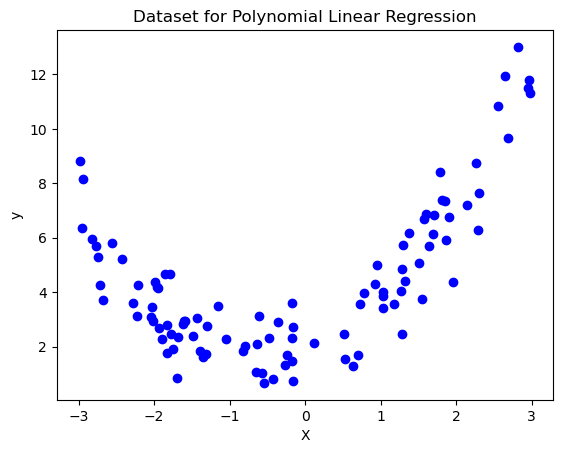

In [17]:
np.random.seed(54)
X = 6*np.random.rand(100, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(100, 1)

plt.scatter(X, y, color='blue')
plt.title('Dataset for Polynomial Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

**Create Polynomial Features**

In [18]:
from sklearn.preprocessing import PolynomialFeatures
poly_tfm = PolynomialFeatures(degree = 2, 
                             interaction_only=False,
                             include_bias=False)

In [19]:
#poly_tfm.fit(X)
#poly_features = poly_tfm.transform(X)
poly_features = poly_tfm.fit_transform(X)

In [20]:
poly_features.shape

(100, 2)

In [21]:
X[0]

array([-0.4789022])

In [22]:
poly_features[0]

array([-0.4789022 ,  0.22934731])

In [23]:
(-0.4789022)**2

0.22934731716484

**Splitting the dataset into the Training set and Test set**

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.2, random_state=54)

**Fitting Linear Regression to the dataset with Polynomial Features**

In [25]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [26]:
print("poly_model.coef_: ", lr.coef_)
print("poly_model.intercept_: ", lr.intercept_)

poly_model.coef_:  [[0.87609787 0.84623229]]
poly_model.intercept_:  [1.92540845]


>  $y = 0.8x^2 + 0.9x + 2$
>- We are not getting the exact coefficients, because of the random noise that we added while creating the dataset

**Evaluate the model**

In [27]:
y_predicted = lr.predict(X_test)
y_predicted.shape, y_test.shape

((20, 1), (20, 1))

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_predicted)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

RMSE:  1.1049482986734123
R2 Score:  0.8718413697606255


> **You can compare these results of Polynomial Linear Regression with Simple Linear Regression:**
>- RMSE:  1.104 vs 2.35
>- R2 Score:  0.87 vs 0.41

**Visualizing the Polynomial Linear Regression results**

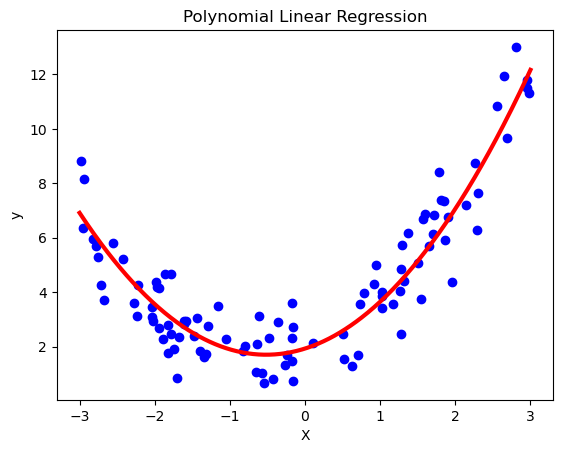

In [29]:
plt.scatter(X, y, color='blue')

X_new=np.linspace(-3, 3, 500).reshape(500, 1)
X_new_poly = poly_tfm.transform(X_new)
y_new = lr.predict(X_new_poly)
plt.plot(X_new, y_new, linewidth=3, color='red')

plt.title('Polynomial Linear Regression')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

**How to choose the optimal degree to create the Polynomial Features?**

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly_tfm.transform(X_new)
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

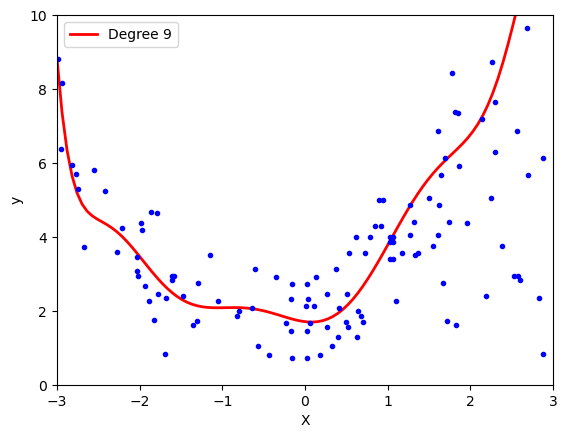

In [31]:
polynomial_regression(9)

#### Model's Parameter vs Model's Hyper-Parameter
- A Machine/Deep Learning `Model's Parameters` are variables which a model learns at its own from the training dataset. 
    - m(slope) and c(intercept) in Linear Regression
    - weights and biases in Neural Networks

- A Machine/Deep Learning `Model's Hyperparameters` are configuration variables that are explicitly defined by the engineer to control the learning process before the model start training. One cannot know the exact best value for hyperparameters for the given problem. The best value can be determined either by the rule of thumb or by trial and error.
    - Learning rate in gradient descent
    - Number of iterations in gradient descent
    - Number of layers in a Neural Network
    - Number of neurons per layer in a Neural Network
    - Number of clusters(k) in k means clustering

# 3. Bias-Variance Tradeoff


## a. Over-Fit vs Under-Fit vs Good-Fit Model

<img align="center" width="1000" src="images/overfit-underfit1.png"  >
    
**Overfitting** occurs when the model is too complex and fits the training data too closely, resulting in poor generalization to new data. An overfit model can be identified if you are getting `low error on training data`, but `high error on test/validation data`. Overfitting can be caused by `high variance and low bias`. A model with high variance is sensitive to small fluctuations in the training data and may fit the training data too closely, leading to poor performance on new data.


**Underfitting** occurs when the model is too simple and cannot capture the underlying patterns in the data, resulting in poor performance on both the training and test data.  An underfit model can be identified if you car getting `high error on both training as well as on test data`. Underfitting can be caused by `high bias and low variance`. A model with high bias is unable to fit the training data well and may perform poorly on both the training and test sets.


**Bias** is the simplifying assumptions made by the model to make the target function easier to approximate. `Increasing bias of your model do underfitting`.

**Variance** tells us how scattered are the predicted value from actual value. A model with high variance pays a lot of attention to training data and does not generalize on test/unseen data. As a result the model perform very well on training data but has high error rates on test data. `Increasing variance of your model do overfitting`.

**Bias-variance trade-off** `Decreasing Bias will increase Variance & Decreasing Variance will increase Bias`. So we need to find the sweet spot where our machine model performs between the errors introduced by the bias and the variance

## b. Bias-Variance Tradeoff

<img src="images/bias-variance-tradeoff.png"  height=2000 align="center">

#### How to prevent overfitting in supervised machine learning?
>- Remove correlated features from your dataset (Forward/Backward selection)
>- Cross Validation (K-fold, Stratified k-fold, Hold-out, Leave-p-out)
>- Hyperparameter Tuning (RandomizedSearchCV, GridSearchCV)
>- Early stopping
>- Regularization  (L1, L2, L1+L2)
>- Ensembling techniques (Bagging and Boosting)

# 4. Multiple Polynomial Linear Regression  (Advertising Data Set)

**Load dataset:**

In [32]:
import numpy as np
import pandas as pd
df = pd.read_csv("datasets/advertising4D.csv")
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [33]:
X = df.drop('sales', axis=1)
y = df['sales']

**Create Polynomial Features**

In [34]:
from sklearn.preprocessing import PolynomialFeatures
poly_tfm = PolynomialFeatures(degree = 2, 
                              interaction_only=False, 
                              include_bias=False)

In [35]:
poly_tfm.fit(X)
poly_features = poly_tfm.transform(X)
print(poly_features)
print(poly_features.shape)

[[ 230.1    37.8    69.2  ... 1428.84 2615.76 4788.64]
 [  44.5    39.3    45.1  ... 1544.49 1772.43 2034.01]
 [  17.2    45.9    69.3  ... 2106.81 3180.87 4802.49]
 ...
 [ 177.      9.3     6.4  ...   86.49   59.52   40.96]
 [ 283.6    42.     66.2  ... 1764.   2780.4  4382.44]
 [ 232.1     8.6     8.7  ...   73.96   74.82   75.69]]
(200, 9)


In [36]:
X.iloc[0,:]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [37]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [38]:
#print("{0:.3f}".format(a))
for a in poly_features[0]:
    print("{0:.2f}".format(a))

230.10
37.80
69.20
52946.01
8697.78
15922.92
1428.84
2615.76
4788.64


In [39]:
#Square terms
230.1**2

52946.009999999995

In [40]:
#Interaction terms
230.1*37.8

8697.779999999999

**Perform Train-Test Split:**

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features , y, test_size=0.2, random_state=54)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 9)
(40, 9)
(160,)
(40,)


**Train Linear Regression Model on Training Dataset with Polynomial Features**

In [42]:
from sklearn.linear_model import LinearRegression
poly_model = LinearRegression()
poly_model.fit(X_train,y_train)

LinearRegression()

In [43]:
print("{0:.2f}".format(a))

4788.64


In [44]:
print("poly_model.coef_: ", poly_model.coef_)
print("poly_model.intercept_: ", poly_model.intercept_)

poly_model.coef_:  [ 5.45417727e-02  1.94824457e-02  1.03435154e-02 -1.18459276e-04
  1.11189977e-03 -5.60767895e-05  1.71315991e-04 -3.26429330e-05
  7.03414270e-06]
poly_model.intercept_:  4.895450491587171


**Evaluate the model**

In [45]:
y_predicted = poly_model.predict(X_test)
test_residuals = y_test - y_predicted

In [46]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_predicted)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

RMSE:  0.4772000856449924
R2 Score:  0.9912759260667968


> **You can compare these results of Polynomial Linear Regression with Multiple Linear Regression:**
>- RMSE:  1.467 vs 0.477
>- R2 Score:  0.9175 vs 0.99

**Choose the optimal degree of Polynomial:**

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("datasets/advertising4D.csv")
X = df.drop('sales', axis=1)
y = df['sales']

train_rmse_errors = []
test_rmse_errors = []

for d in range(1,6):
    # Create poly data set for degree d=1,2,3,4,5 in each loop iteration
    polynomial_converter = PolynomialFeatures(degree=d,include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)
    
    # Split this new poly data set
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    # Create LR model and train it on new polynomial feature set
    model = LinearRegression()
    model.fit(X_train,y_train)
    
    # Predict on both train and test data
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Compute Errors on Train and Test Set and append to lists
    train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))
    test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))
    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

In [48]:
train_rmse_errors

[1.7345941243293763,
 0.5879574085292231,
 0.43393443569020684,
 0.35170836883993534,
 0.250934296316856]

In [49]:
test_rmse_errors

[1.5161519375993884,
 0.6646431757268985,
 0.5803286825163761,
 0.5077742631180224,
 2.575820709711997]

**Plot the training and test errors against model complexity to understand overfitting:**

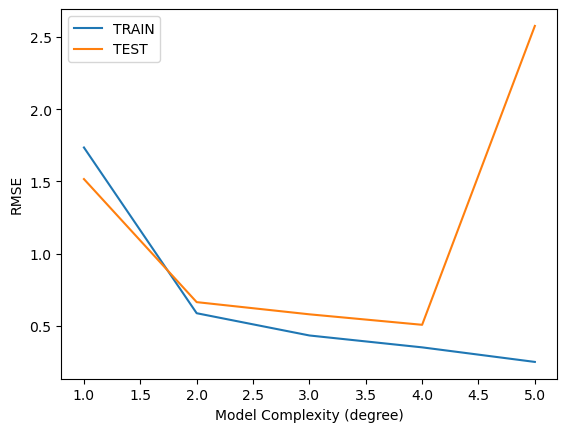

In [50]:
plt.plot(range(1,6),train_rmse_errors,label='TRAIN')
plt.plot(range(1,6),test_rmse_errors,label='TEST')
plt.xlabel("Model Complexity (degree)")
plt.ylabel("RMSE")
plt.legend();

**Note:**
>- For the degree of 1, the prediction error is high on both the training as well as the test data, so that means the model underfits for the degree of 1.
>- By increasing the degree upto 4, the prediction error goes down, but after that  the prediction error on test data increases exponentially, while prediction error on training data decreases. That means the model overfits for degrees greater than 4.
>- So the sweat spot for this dataset is roughly a degree of 3, in which case both the bias and variance are moderately low.

<img align="left" width="600" height=500 src="images/bias-variance11.png" >

# Question

In [27]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
X = pd.DataFrame({
                'x1':[3, 2, 5],
                'x2':[6, 7, 1],
                'x3':[2, 4, 3],
                'x4':[2, 1, 6]
                })
X

,x1,x2,x3,x4
0,3,6,2,2
1,2,7,4,1
2,5,1,3,6


In [25]:
poly_tfm = PolynomialFeatures(degree = 2, 
                              interaction_only=True, 
                              include_bias=False)
poly_tfm.fit(X)
poly_features = poly_tfm.transform(X)
print(poly_features)
print(poly_features.shape)

[[ 3.  6.  2.  2. 18.  6.  6. 12. 12.  4.]
 [ 2.  7.  4.  1. 14.  8.  2. 28.  7.  4.]
 [ 5.  1.  3.  6.  5. 15. 30.  3.  6. 18.]]
(3, 10)


In [28]:
poly_tfm = PolynomialFeatures(degree = 2, 
                              interaction_only=False, 
                              include_bias=False)
poly_tfm.fit(X)
poly_features = poly_tfm.transform(X)
print(poly_features)
print(poly_features.shape)

[[ 3.  6.  2.  2.  9. 18.  6.  6. 36. 12. 12.  4.  4.  4.]
 [ 2.  7.  4.  1.  4. 14.  8.  2. 49. 28.  7. 16.  4.  1.]
 [ 5.  1.  3.  6. 25.  5. 15. 30.  1.  3.  6.  9. 18. 36.]]
(3, 14)
